<a href="https://colab.research.google.com/github/toplubster/Biocoding-Stuffs-/blob/main/BCA%20Protein%20Assay%20Concentration%20Calculator%20(4.0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BCA Protein Assay Concentration Calculator (3.0)

## **Purpose:** This was created to assist with data plotting and data calculations for BCA protein concentration assay



---



###**Default Values (Chart title, axis titles, units)**

``assay_name       = 'Protein Assay'``

``wavelength       = 562 (nm)``

``conc_units       = 'mg/mL'  ``

``concentration_col = 'Concentration_mg_per_mL'``

``replicate_cols   = ['Rep1', 'Rep2']``


> If you would like to modify any of these, you will have to modify the code cell in **step 1**.



> If you have any questions, please reach out to me at hieuu.nguyen2511@gmail.com ginopark41@gmail.com
or
Professor Novak at novakw@wabash.edu






# Step 1: Importing Libraries and Data Acquisition (RUN THIS CELL)

In [6]:
#@title Run this cell to import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import urllib.request
import os

print("✅ All libraries imported successfully!")

# ─────────────────────────────────────────────────────────
# 🔧 TEMPLATE MODIFICATION POINT — Change these five variables
# ─────────────────────────────────────────────────────────

assay_name       = 'BCA Protein Assay'   # 🔧 Your assay name
wavelength       = 562                         # 🔧 Measurement wavelength (nm)
conc_units       = 'mg/mL'                    # 🔧 Concentration units
concentration_col = 'Concentration_mg_per_mL' # 🔧 First column name in your CSV
replicate_cols   = ['Rep1', 'Rep2']   # 🔧 Replicate column names

# ─────────────────────────────────────────────────────────
# No changes needed below this line
# ─────────────────────────────────────────────────────────
print(f"✅ Parameters set:")
print(f"   Assay:       {assay_name}")
print(f"   Wavelength:  {wavelength} nm")
print(f"   Units:       {conc_units}")
print(f"   Conc column: {concentration_col}")
print(f"   Replicates:  {replicate_cols}")

✅ All libraries imported successfully!
✅ Parameters set:
   Assay:       BCA Protein Assay
   Wavelength:  562 nm
   Units:       mg/mL
   Conc column: Concentration_mg_per_mL
   Replicates:  ['Rep1', 'Rep2']


# Step 2: Uploading Data and Checking Data (RUN THIS CELL)


> 🔧 ** IMPORTANT NOTE**
> Your data must have:
> - One column of **concentration values** (your x-axis)
> - One or more columns of **replicate measurements** (your y-axis readings)
> - Column names that **exactly match** `concentration_col`
>   and `replicate_cols` defined in Section 3a
> - All of your samples name column
> - One or more Unknown Replicates column
> - Dilution for each sample


> ## **IMPORTANT:** Make sure your .csv file format is exactly as the example below or I will crash out. Use the TEMPLATE down. Generate the template, then download.



---

## Generate a Template CSV File

Run the cell below to generate a template CSV file with the correct headers. You can download this file, fill in your data, and then upload it back to Colab using one of the methods above.

In [7]:
#@title Generate a template csv file
import pandas as pd

# Ensure these variables are defined for the template creation
concentration_col = 'Concentration_mg_per_mL'
replicate_cols   = ['Rep1', 'Rep2']

# Define the column names based on the expected format
# Using the variables defined in Section 3a for consistency
column_names = [
    concentration_col,
    replicate_cols[0],
    replicate_cols[1],
    'Sample',
    'Unk_rep1',
    'Unk_rep2',
    'Dilution'
]

# Create an empty DataFrame with these column names
template_df = pd.DataFrame(columns=column_names)

# Optionally, add a row of example data or placeholder values
# For simplicity, we'll keep it empty for now, or add a single blank row.
# template_df.loc[0] = ['', '', '', '', '', '', ''] # Uncomment to add an empty row

# Define the filename for the template
template_filename = 'data_template.csv'

# Export the empty DataFrame to a CSV file
template_df.to_csv(template_filename, index=False)

print(f"✅ Template CSV '{template_filename}' created successfully!")
print(f"You can download this file from the Colab file browser (folder icon 📁 on the left) or by running the next cell.")

display(template_df)

✅ Template CSV 'data_template.csv' created successfully!
You can download this file from the Colab file browser (folder icon 📁 on the left) or by running the next cell.


,Concentration_mg_per_mL,Rep1,Rep2,Sample,Unk_rep1,Unk_rep2,Dilution


In [19]:
#@title Download the template CSV file
from google.colab import files
files.download(template_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



#### What Your CSV Must Look Like

Your CSV file must have the following structure or something like this:

| Concentration_mg_per_mL | Rep1 | Rep2 | Sample | Unk_rep1 | Unk_rep2 | Dilution |
|---|---|---|---|---|---|---|
| 0 | 0.1049 | 0.1048 | N2 | 0.4319 | 0.4268 | 25 |
| 0.025 | 0.1149 | 0.1201 | N2 40 | 0.2533 | 0.2564 | 40 |
| 0.125 | 0.1672 | 0.1676 | N2 50 | 0.1916 | 0.1924 | 50 |
| 0.25 | 0.2344 | 0.2312 | lon 25 | 0.3434 | 0.3319 | 25 |
| 0.5 | 0.3528 | 0.3441 | lon 40 | 0.2786 | 0.2586 | 40 |
| 0.75 | 0.5133 | 0.3801 | lon 50 | 0.3227 | 0.2306 | 50 |
| 1 | 0.5203 | 0.5114 | svh 25 | 0.2663 | 0.2707 | 25 |
| 1.5 | 0.8098 | 0.761 | svh 40 | 0.2184 | 0.226 | 40 |
| 2 | 1.0645 | 0.9611 | svh 50 | 0.2076 | 0.1864 | 50 |
| | | | con 25 | 0.4348 | 0.425 | 25 |
| | | | con 40 | 0.252 | 0.2483 | 40 |
| | | | con 50 | 0.3505 | 0.309 | 50 |
| | | | K12 25 | 0.376 | 0.4021 | 25 |
| | | | K12 40 | 0.2195 | 0.2405 | 40 |
| | | | K12 50 | 0.2309 | 0.2683 | 50 |
| | | | tpp 25 | 0.5013 | 0.5081 | 25 |
| | | | tpp 40 | 0.3444 | 0.3365 | 40 |
| | | | tpp 50 | 0.2595 | 0.296 | 50 |

**Rules:**
- The **first row** must be a header row with column names
- The **first column** must contain your concentration values
- The **remaining columns** must contain replicate measurements
- Column names must **exactly match** `concentration_col` and
  `replicate_cols` defined above.
- Please refer to the example above to make an appropriate `.csv` file (All **column names** must match!
- Values must be **numbers only** except for sample names— no units in the data cells
- Save the file as `.csv` (Comma Separated Values)

> **In Excel or Google Sheets:**
> File → Download → Comma Separated Values (.csv)

---

#### How to Upload to Colab

There are two ways:

**Method 1 — Drag and drop:**
1. Click the **folder icon (📁)** in the left panel
2. Drag your CSV file from your computer into the panel

**Method 2 — Upload dialog (used in the code below):**
1. Run the cell below
2. Click **Choose Files** in the dialog that appears
3. Navigate to and select your CSV file
4. Wait for the upload to complete









> ## **You will only need to use either one of the methods**

In [21]:
#@title **Method 1:** Upload your own CSV file from your computer


from google.colab import files

print("A file chooser dialog will appear below.")
print("Select your CSV file and wait for the upload to complete.")
print()

# This opens the file upload dialog
uploaded = files.upload()

# 🔧 If your file has a different name, update it here
# The filename is shown after upload completes
uploaded_filename = list(uploaded.keys())[0]

print(f"\n✅ File uploaded: {uploaded_filename}")

# Read the uploaded file into a DataFrame
df = pd.read_csv(uploaded_filename)

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("Column names found in your file:")
print(list(df.columns))
print()
print("⚠️  Check that column names match concentration_col and")
print(f"   replicate_cols defined in Section 3a:")
print(f"   concentration_col = '{concentration_col}'")
print(f"   replicate_cols    = {replicate_cols}")

# Verify your data — run this regardless of which option you used
'''
Check that:
- The **shape** matches the number of rows and columns you expect
- The **column names** match what you defined in Section 3a
- The **data types** are numeric (`float64` or `int64`) for all columns, sample column data type can be different
- The **head** shows sensible values — no obvious errors
'''

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("Column names:")
print(list(df.columns))
print()
print("Data types:")
print(df.dtypes)

# Replace NaN values with blank strings for display
display(df.fillna(''))

A file chooser dialog will appear below.
Select your CSV file and wait for the upload to complete.



Saving Book3(in) test.csv to Book3(in) test (1).csv

✅ File uploaded: Book3(in) test (1).csv
Shape: 10 rows × 7 columns

Column names found in your file:
['Concentration_mg_per_mL', 'Rep1', 'Rep2', 'Sample', 'Unk_rep1', 'Unk_rep2', 'Dilution']

⚠️  Check that column names match concentration_col and
   replicate_cols defined in Section 3a:
   concentration_col = 'Concentration_mg_per_mL'
   replicate_cols    = ['Rep1', 'Rep2']
Shape: 10 rows × 7 columns

Column names:
['Concentration_mg_per_mL', 'Rep1', 'Rep2', 'Sample', 'Unk_rep1', 'Unk_rep2', 'Dilution']

Data types:
Concentration_mg_per_mL    float64
Rep1                       float64
Rep2                       float64
Sample                      object
Unk_rep1                   float64
Unk_rep2                   float64
Dilution                     int64
dtype: object


,Concentration_mg_per_mL,Rep1,Rep2,Sample,Unk_rep1,Unk_rep2,Dilution
0,0.0,0.1166,0.1168,NP 25,0.1919,0.1900,25
1,0.025,0.126,0.125,NP 40,0.1888,0.1773,40
2,0.125,0.2091,0.1969,NP 50,0.1662,0.1594,50
3,0.25,0.2919,0.2322,KO 25,0.2193,0.2344,25
4,0.5,0.4205,0.3043,KO 40,0.1727,0.1831,40
5,0.75,0.6982,0.8647,KO 50,0.1614,0.1890,50
6,1.0,0.5998,0.4165,AT 25,0.1884,0.2133,25
7,1.5,1.0038,0.7978,AT 40,0.1622,0.1571,40
8,2.0,1.3838,1.1097,AT 50,0.1487,0.1485,50
9,,,,X sample,1.5000,1.5000,50


In [ ]:
#@title **Method 2:** Option to load CSV directly from the Colab notebook folder by typing the filename
import pandas as pd

print("Enter the filename of your CSV file (e.g., 'my_data.csv'):")
filename = input()

try:
    # Read the specified file into a DataFrame
    df = pd.read_csv(filename)

    print(f"\n✅ File loaded: {filename}")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print()
    print("Column names found in your file:")
    print(list(df.columns))
    print()
    print("⚠️  Check that column names match concentration_col and")
    print(f"   replicate_cols defined in Section 3a:")
    print(f"   concentration_col = '{concentration_col}'")
    print(f"   replicate_cols    = {replicate_cols}")

    # Verify your data
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print()
    print("Column names:")
    print(list(df.columns))
    print()
    print("Data types:")
    print(df.dtypes)

    # Replace NaN values with blank strings for display
    display(df.fillna(''))

except FileNotFoundError:
    print(f"Error: The file '{filename}' was not found in your Colab environment. Please ensure the file name is correct and it is in the /content/ folder.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

#Step 3: Calculations
## 3.1 Calculating the Average and Standard Deviation (RUN THIS CELL)

Each concentration point was measured multiple times (one reading
per replicate column). We collapse these into:
- **Average** — the central value we will plot and fit
- **Standard deviation** — the spread we will show as error bars

In [22]:
#@title Calculate average and standard deviation across replicates
# Uses replicate_cols defined in Section 3a — no changes needed here

# Filter df to include only standard curve points
std_data_df = df[df[concentration_col].notna()].copy()

# Average across replicate columns for each row
std_data_df['average'] = std_data_df[replicate_cols].mean(axis=1)

# Standard deviation across replicate columns for each row
std_data_df['std_dev'] = std_data_df[replicate_cols].std(axis=1)

# Zeroing the absorbance relative to the first (blank) standard
std_data_df['zeroed'] = std_data_df['average'] - std_data_df['average'].iloc[0]

# Display only the specified columns in the desired order
display(std_data_df[[concentration_col, 'Rep1', 'Rep2', 'average', 'std_dev', 'zeroed']])



,Concentration_mg_per_mL,Rep1,Rep2,average,std_dev,zeroed
0,0.000,0.1166,0.1168,0.11670,0.000141,0.00000
1,0.025,0.1260,0.1250,0.12550,0.000707,0.00880
2,0.125,0.2091,0.1969,0.20300,0.008627,0.08630
3,0.250,0.2919,0.2322,0.26205,0.042214,0.14535
4,0.500,0.4205,0.3043,0.36240,0.082166,0.24570
5,0.750,0.6982,0.8647,0.78145,0.117733,0.66475
6,1.000,0.5998,0.4165,0.50815,0.129613,0.39145
7,1.500,1.0038,0.7978,0.90080,0.145664,0.78410
8,2.000,1.3838,1.1097,1.24675,0.193818,1.13005


## 3.2 Fitting the Curve: Nonlinear Regression (RUN THIS CELL)



BCA Protein Assay — Polynomial Regression (Degree 2) Results
  a (quadratic): -0.001925
  b (linear):    0.5455
  c (intercept): 0.0130
  R²:            0.9265

Fit quality: Check your data ❌


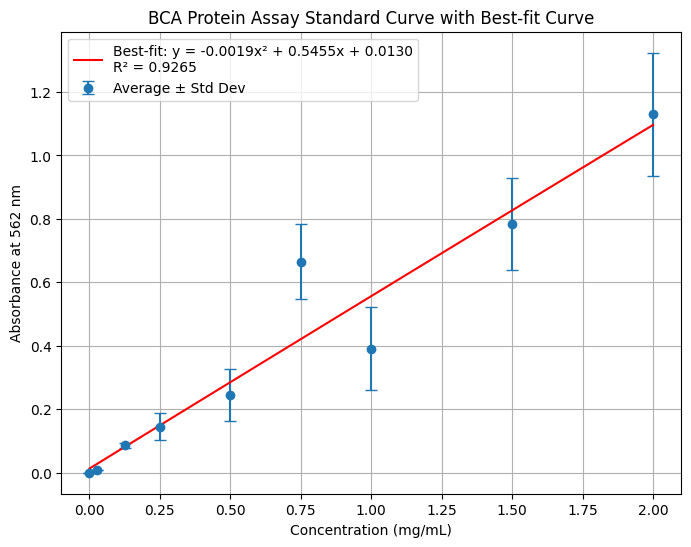

In [24]:

#@title Plotting and Finding The Best Fit Curve
import numpy as np # Ensure numpy is imported

# Step 1: Store the full result object and explore it

# Use the filtered standard curve data for regression
concentration      = std_data_df[concentration_col]
average_absorbance = std_data_df['zeroed']

# Use numpy.polyfit to find the coefficients for a quadratic model: y = ax² + bx + c
# popt will contain [a, b, c]
popt = np.polyfit(concentration, average_absorbance, 2)

# Unpack parameters
a, b, c = popt

# Define a function to evaluate the polynomial for residuals and plotting
def model_poly(x, popt_coeffs):
    return np.polyval(popt_coeffs, x)

# Calculate R² manually from residuals
residuals = average_absorbance - model_poly(concentration, popt)
ss_res    = np.sum(residuals**2)
ss_tot    = np.sum((average_absorbance - np.mean(average_absorbance))**2)
r_squared = 1 - (ss_res / ss_tot)

# Print a clean summary
print(f"{assay_name} — Polynomial Regression (Degree 2) Results")
print("=" * 45)
print(f"  a (quadratic): {a:.6f}")
print(f"  b (linear):    {b:.4f}")
print(f"  c (intercept): {c:.4f}")
print(f"  R²:            {r_squared:.4f}")
print()

# Evaluate fit quality
if r_squared >= 0.99:
    print("Fit quality: Excellent ✅")
elif r_squared >= 0.95:
    print("Fit quality: Acceptable ⚠️")
else:
    print("Fit quality: Check your data ❌")

# Plot with best-fit curve

# Generate 100 evenly-spaced points for a smooth curve
curve_x = np.linspace(concentration.min(), concentration.max(), 100)
curve_y = model_poly(curve_x, popt)

plt.figure(figsize=(8, 6))

# Error bar data points
plt.errorbar(
    concentration,
    average_absorbance,
    yerr=std_data_df['std_dev'], # Use std_data_df['std_dev'] for correct length
    fmt='o',
    capsize=4,
    label='Average ± Std Dev'
)

# Best-fit curve
plt.plot(
    curve_x, curve_y,
    color='red',
    label=f'Best-fit: y = {a:.4f}x² + {b:.4f}x + {c:.4f}\nR² = {r_squared:.4f}'
)

plt.xlabel(f'Concentration ({conc_units})')
plt.ylabel(f'Absorbance at {wavelength} nm')
plt.title(f'{assay_name} Standard Curve with Best-fit Curve')
plt.grid(True)
plt.legend()
plt.show()

> ### If fit quality is "Check your data ❌," don't panic. Try to look at the .csv file or your data again.



## **Predicting Concentration from Absorbance** (RUN THIS CELL)



⚠️  WARNING: Some unknown sample absorbances fall outside the range of your standard curve.
   - 0 samples have absorbances below the lowest standard (0.0000).
   - 1 samples have absorbances above the highest standard (1.1300).
   These points may yield less reliable concentration predictions.
   Consider adjusting your standard curve range or diluting/concentrating samples as needed.

--- Samples with absorbances above standard curve range ---


,Sample,Unk_Zeroed_Abs
9,X sample,1.3833


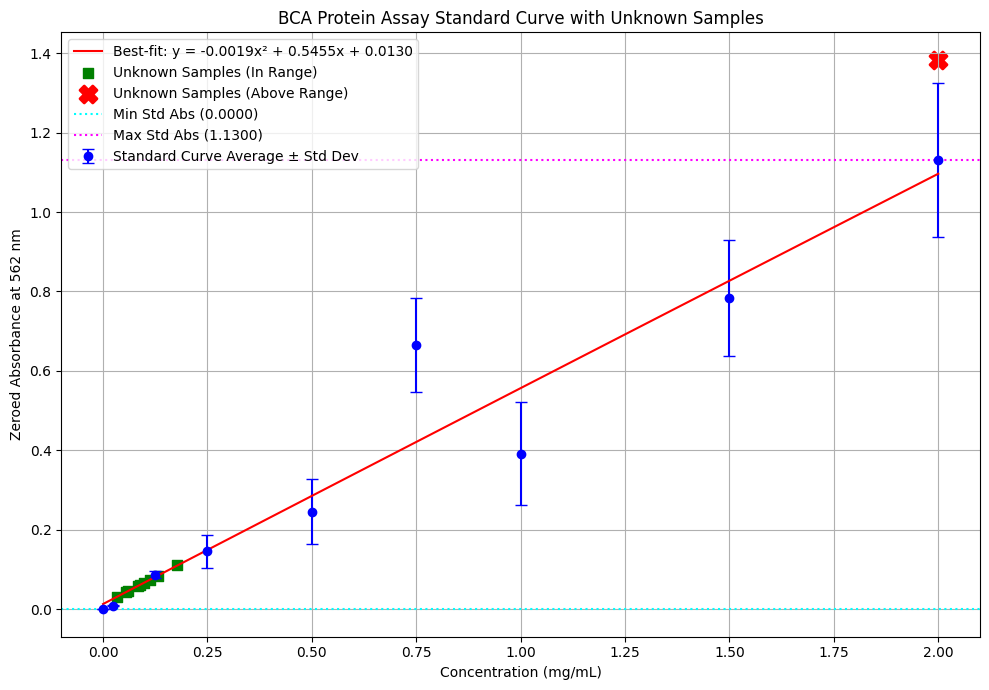

In [36]:
#@title Check if there are any points outside of the known range

# --- Original content of this cell (df_unk definition and range checks) ---
unknown_replicate_cols = ['Unk_rep1', 'Unk_rep2']

df_unk = df[
    df[unknown_replicate_cols].notna().any(axis=1)
].copy()

df_unk = df_unk.dropna(subset=unknown_replicate_cols)

# replicate average
df_unk['Unk_Average_Abs'] = df_unk[unknown_replicate_cols].mean(axis=1)

# proper blank selection
# blank_average is defined from std_data_df which is available.
blank_average = std_data_df.loc[
    std_data_df['Concentration_mg_per_mL'] == 0,
    'average'
].values[0]

# zeroing
df_unk['Unk_Zeroed_Abs'] = df_unk['Unk_Average_Abs'] - blank_average


# Get the min and max of the zeroed standard curve absorbances
min_std_abs = std_data_df['zeroed'].min()
max_std_abs = std_data_df['zeroed'].max()

# Identify unknown absorbances below the standard curve range
below_range_count = df_unk[df_unk['Unk_Zeroed_Abs'] < min_std_abs].shape[0]

# Identify unknown absorbances above the standard curve range
above_range_count = df_unk[df_unk['Unk_Zeroed_Abs'] > max_std_abs].shape[0]

if below_range_count > 0 or above_range_count > 0:
    print("⚠️  WARNING: Some unknown sample absorbances fall outside the range of your standard curve.")
    print(f"   - {below_range_count} samples have absorbances below the lowest standard ({min_std_abs:.4f}).")
    print(f"   - {above_range_count} samples have absorbances above the highest standard ({max_std_abs:.4f}).")
    print("   These points may yield less reliable concentration predictions.")
    print("   Consider adjusting your standard curve range or diluting/concentrating samples as needed.")
else:
    print("✅ All unknown sample absorbances are within the range of the standard curve.")

# Displaying out-of-range points for user review
if below_range_count > 0:
    print("\n--- Samples with absorbances below standard curve range ---")
    display(df_unk[df_unk['Unk_Zeroed_Abs'] < min_std_abs][['Sample', 'Unk_Zeroed_Abs']])

if above_range_count > 0:
    print("\n--- Samples with absorbances above standard curve range ---")
    display(df_unk[df_unk['Unk_Zeroed_Abs'] > max_std_abs][['Sample', 'Unk_Zeroed_Abs']])


# --- New code for plotting the standard curve with unknown samples ---
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported

# Redo standard curve fitting parameters (copied from 321PWe_DncWj)
concentration_std = std_data_df[concentration_col]
average_absorbance_std = std_data_df['zeroed']

popt = np.polyfit(concentration_std, average_absorbance_std, 2)

# Unpack parameters
a, b, c = popt

# Define a function to evaluate the polynomial for residuals and plotting
def model_poly(x, popt_coeffs):
    return np.polyval(popt_coeffs, x)

# Define solve_concentration locally for plotting purposes (copied from 9bdm4-bvH7L8)
def solve_concentration(y, a_val, b_val, c_val, x_min_val, x_max_val):
    # ax^2 + bx + (c - y) = 0
    A = a_val
    B = b_val
    C = c_val - y

    discriminant = B**2 - 4 * A * C

    if discriminant < 0:
        return np.nan

    sqrt_d = np.sqrt(discriminant)

    root1 = (-B + sqrt_d) / (2 * A)
    root2 = (-B - sqrt_d) / (2 * A)

    # keep only physically valid roots (within calibration range) - This part is what causes NaN for out-of-range
    valid_roots = [
        r for r in [root1, root2]
        if x_min_val <= r <= x_max_val
    ]

    if len(valid_roots) == 0:
        return np.nan

    return valid_roots[0]


# --- Plotting ---
plt.figure(figsize=(10, 7))

# Generate 100 evenly-spaced points for a smooth curve
curve_x = np.linspace(concentration_std.min(), concentration_std.max(), 100)
curve_y = model_poly(curve_x, popt)

# Plot standard curve data points
plt.errorbar(
    concentration_std,
    average_absorbance_std,
    yerr=std_data_df['std_dev'],
    fmt='o',
    capsize=4,
    label='Standard Curve Average \u00b1 Std Dev',
    color='blue'
)

# Plot best-fit curve
plt.plot(
    curve_x, curve_y,
    color='red',
    label=f'Best-fit: y = {a:.4f}x\u00b2 + {b:.4f}x + {c:.4f}' # R^2 not calculated here, it's already in 321PWe_DncWj
)

# Separate in-range and out-of-range unknown samples
in_range_samples = df_unk[
    (df_unk['Unk_Zeroed_Abs'] >= min_std_abs) &
    (df_unk['Unk_Zeroed_Abs'] <= max_std_abs)
].copy()
out_of_range_samples = df_unk[
    (df_unk['Unk_Zeroed_Abs'] < min_std_abs) |
    (df_unk['Unk_Zeroed_Abs'] > max_std_abs)
].copy()

# Get x_min and x_max for solve_concentration (from std curve concentration range)
x_min_std_conc = std_data_df[concentration_col].min()
x_max_std_conc = std_data_df[concentration_col].max()


# Plot in-range unknown points in green
in_range_samples['predicted_conc_for_plot'] = in_range_samples['Unk_Zeroed_Abs'].apply(
    lambda y_val: solve_concentration(y_val, a, b, c, x_min_std_conc, x_max_std_conc)
)
plt.scatter(
    in_range_samples['predicted_conc_for_plot'],
    in_range_samples['Unk_Zeroed_Abs'],
    color='green',
    marker='s', # Use squares for unknown samples
    s=50,       # Size of markers
    label='Unknown Samples (In Range)'
)

# Plot out-of-range unknown points in red
# For out-of-range points, we'll plot them at the min/max concentration of the standard curve
# to visually represent their 'out of range' status without generating NaNs.
out_of_range_above = out_of_range_samples[out_of_range_samples['Unk_Zeroed_Abs'] > max_std_abs].copy()
out_of_range_below = out_of_range_samples[out_of_range_samples['Unk_Zeroed_Abs'] < min_std_abs].copy()

if not out_of_range_above.empty:
    plt.scatter(
        [x_max_std_conc] * len(out_of_range_above), # Plot at max std curve concentration
        out_of_range_above['Unk_Zeroed_Abs'],
        color='red',
        marker='X',
        s=150,  # Increased size
        linewidth=2, # Added linewidth
        label='Unknown Samples (Above Range)'
    )

if not out_of_range_below.empty:
    plt.scatter(
        [x_min_std_conc] * len(out_of_range_below), # Plot at min std curve concentration
        out_of_range_below['Unk_Zeroed_Abs'],
        color='red',
        marker='X',
        s=150,  # Increased size
        linewidth=2, # Added linewidth
        label='Unknown Samples (Below Range)'
    )

# Add horizontal lines for min and max standard curve absorbances on the plot
plt.axhline(y=min_std_abs, color='cyan', linestyle=':', label=f'Min Std Abs ({min_std_abs:.4f})')
plt.axhline(y=max_std_abs, color='magenta', linestyle=':', label=f'Max Std Abs ({max_std_abs:.4f})')


plt.xlabel(f'Concentration ({conc_units})')
plt.ylabel(f'Zeroed Absorbance at {wavelength} nm')
plt.title(f'{assay_name} Standard Curve with Unknown Samples')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


In [32]:
#@title Calculate Concentration and provide a table of values

import numpy as np
import pandas as pd

# ----------------------------
# 1. QUADRATIC SOLVER (fixed)
# ----------------------------
def solve_concentration(y, a, b, c, x_min, x_max):

    # ax^2 + bx + (c - y) = 0
    A = a
    B = b
    C = c - y

    discriminant = B**2 - 4*A*C

    if discriminant < 0:
        return np.nan

    sqrt_d = np.sqrt(discriminant)

    root1 = (-B + sqrt_d) / (2*A)
    root2 = (-B - sqrt_d) / (2*A)

    # keep only physically valid roots (within calibration range)
    valid_roots = [
        r for r in [root1, root2]
        if x_min <= r <= x_max
    ]

    if len(valid_roots) == 0:
        return np.nan

    return valid_roots[0]  # safe pick within range


# ----------------------------
# 2. BUILD UNKNOWN DATAFRAME
# ----------------------------
unknown_replicate_cols = ['Unk_rep1', 'Unk_rep2']

df_unk = df[
    df[unknown_replicate_cols].notna().any(axis=1)
].copy()

df_unk = df_unk.dropna(subset=unknown_replicate_cols)

# replicate average
df_unk['Unk_Average_Abs'] = df_unk[unknown_replicate_cols].mean(axis=1)


# ----------------------------
# 3. PROPER BLANK SELECTION (FIXED)
# ----------------------------
blank_average = std_data_df.loc[
    std_data_df['Concentration_mg_per_mL'] == 0,
    'average'
].values[0]


# zeroing
df_unk['Unk_Zeroed_Abs'] = df_unk['Unk_Average_Abs'] - blank_average


# ----------------------------
# 4. STANDARD CURVE RANGE
# ----------------------------
x_min = std_data_df['Concentration_mg_per_mL'].min()
x_max = std_data_df['Concentration_mg_per_mL'].max()


# ----------------------------
# 5. MEASURED CONCENTRATION
# ----------------------------
df_unk['measured_conc'] = df_unk['Unk_Zeroed_Abs'].apply(
    lambda y: solve_concentration(y, a, b, c, x_min, x_max)
)


# ----------------------------
# 6. DILUTION CORRECTION
# ----------------------------
df_unk['corrected_conc'] = df_unk['measured_conc'] * df_unk['Dilution']


# ----------------------------
# 7. BACK-CALCULATED ABSORBANCE
# ----------------------------
df_unk['predicted_absorbance'] = (
    a * df_unk['measured_conc']**2 +
    b * df_unk['measured_conc'] +
    c
)


# ----------------------------
# 8. RESIDUAL ERROR
# ----------------------------
df_unk['residual_error'] = (
    df_unk['Unk_Zeroed_Abs'] - df_unk['predicted_absorbance']
)


# ----------------------------
# 9. FINAL TABLE
# ----------------------------
result_table = df_unk[[
    'Sample',
    'Unk_rep1',
    'Unk_rep2',
    'Unk_Zeroed_Abs',
    'Dilution',
    'measured_conc',
    'corrected_conc',
    'residual_error'
]].copy()


result_table.rename(columns={
    'Sample': 'Sample_Name',
    'Unk_rep1': 'Rep1',
    'Unk_rep2': 'Rep2',
    'Unk_Zeroed_Abs': f'Unk_Zeroed_Abs ({wavelength} nm)',
    'Dilution': 'Dilution_Factor',
    'measured_conc': f'Measured_Concentration ({conc_units})',
    'corrected_conc': f'Corrected_Concentration ({conc_units})',
    'residual_error': 'Residual_Error_Absorbance'
}, inplace=True)


# format residuals
result_table['Residual_Error_Absorbance'] = result_table[
    'Residual_Error_Absorbance'
].apply(lambda x: f"{x:.2e}" if pd.notna(x) else np.nan)


print("Final Concentration Table:")
display(result_table.round(6))

Final Concentration Table:


,Sample_Name,Rep1,Rep2,Unk_Zeroed_Abs (562 nm),Dilution_Factor,Measured_Concentration (mg/mL),Corrected_Concentration (mg/mL),Residual_Error_Absorbance
0,NP 25,0.1919,0.1900,0.07425,25,0.112290,2.807250,4.86e-16
1,NP 40,0.1888,0.1773,0.06635,40,0.097798,3.911920,-4.66e-15
2,NP 50,0.1662,0.1594,0.04610,50,0.060658,3.032877,3.16e-15
3,KO 25,0.2193,0.2344,0.11015,25,0.178165,4.454119,4.58e-16
4,KO 40,0.1727,0.1831,0.06120,40,0.088351,3.534059,1.45e-15
5,KO 50,0.1614,0.1890,0.05850,50,0.083399,4.169959,5.98e-15
6,AT 25,0.1884,0.2133,0.08415,25,0.130453,3.261324,-6.72e-15
7,AT 40,0.1622,0.1571,0.04295,40,0.054881,2.195240,-3.07e-15
8,AT 50,0.1487,0.1485,0.03190,50,0.034619,1.730959,1.47e-15
9,X sample,1.5000,1.5000,1.38330,50,NaN,NaN,NaN


# Step 4: Exporting A CSV File for Samples (RUN THIS CELL)
- The CSV file will be similar to the *Predicting Concentration from Absorbance* table

In [ ]:
#@title Exporting the 'Predicting Concentration from Absorbance' table to a CSV file

print("Enter the filename for the exported CSV (e.g., 'unknown_concentrations'):")
export_filename_base = input()

# Ensure the filename ends with .csv
if not export_filename_base.endswith('.csv'):
    export_filename = export_filename_base + '.csv'
else:
    export_filename = export_filename_base

try:
    # Save the df_unk DataFrame to a CSV file
    # index=False prevents pandas from writing the DataFrame index as a column in the CSV
    df_unk.to_csv(export_filename, index=False)
    print(f"\n✅ Successfully exported '{export_filename}'")
    print("You can find this file in the Colab file browser (folder icon 📁 on the left). (Hit the refresh button🔄️))")
except Exception as e:
    print(f"An error occurred while exporting the file: {e}")